## langgraph概述

**LangGraph** 是 LangChain 团队开发的开源框架（MIT 许可），专为构建**可靠、可控的状态化、多代理（Multi-Agent）AI 应用**而设计。

### 核心定位
- **LangChain** 更适合简单的链式（Chain）工作流（线性步骤）。
- **LangGraph** 则专注于**复杂、动态、带循环和分支**的 Agent 编排，属于低级编排框架，提供更高的控制力和生产级能力（持久化、容错、Human-in-the-Loop 等）。

### 主要特点
- 图结构（Graph）：将应用建模为**节点（Nodes）** + **边（Edges）**，节点可以是 LLM 调用、工具执行、决策等，边支持条件跳转和循环。
- 状态管理（State）：全程维护共享状态，支持持久化（即使中断也能恢复）。
- 关键能力：
  - 持久执行（Durable Execution）：长时间运行、故障恢复。
  - 流式输出（Streaming）。
  - 人类介入（Human-in-the-Loop）。
  - 多代理协作。
  - 检查点（Checkpoint）与内存。

### 适用场景
- 复杂 Agent 系统（如需要多次工具调用、反思、规划的场景）。
- 多代理协作工作流。
- 需要高可靠性、生产部署的 AI 应用。

简单来说，**LangGraph 让你像画流程图一样构建 AI 智能体**，比传统 LangChain Agents 更灵活、更可靠，是目前构建生产级 Agent 的主流选择之一。



## Node
Node是Langgraph中最基本的单元，代表工作流中的一个步骤或操作。每个Node可以执行特定的任务，如调用语言模型、执行工具、进行决策等。Node之间通过边（Edges）连接，形成一个有向图（Directed Graph），表示工作流的流程和逻辑。  

本质：
- 一个接受State、处理后返回State的函数。
- 可以是LLM调用、工具执行、条件判断等。  

在langgraph中，Node有以下几种等价的定义方式：
1. **函数定义**：直接定义一个接受State并返回State的函数。
2. **类定义**：通过继承Node类，定义一个具有特定行为的Node。
3. **装饰器定义**：使用@node装饰器将一个普通函数转换为Node。




In [1]:
# 加载环境变量
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
from langchain_deepseek import ChatDeepSeek
from langchain.tools import tool
from langchain.messages import AnyMessage

In [3]:
llm_ds = ChatDeepSeek(model='deepseek-chat',
                 api_key=os.getenv('DEEPSEEK_API_KEY'),
                      )

In [8]:
# 1. 定义工具和模型
@tool
def multiply(a: int, b: int) -> int:
    """Multiply `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a * b


@tool
def add(a: int, b: int) -> int:
    """Adds `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a + b


@tool
def divide(a: int, b: int) -> float:
    """Divide `a` and `b`.

    Args:
        a: First int
        b: Second int
    """
    return a / b

tools = [multiply, add, divide]
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = llm_ds.bind_tools(tools)

In [11]:
# 2.定义状态
# 图的状态用于存储消息，以及LLM调用次数
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
import operator
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

In [16]:
# 3. 定义模型节点
from langchain.messages import SystemMessage
def llm_node(state:dict):
    """
    模型将决定是否使用工具，以及使用哪个工具，并将结果添加到状态中。
    :param state: 
    :return: state
    """
    return {
        'messages':[
            model_with_tools.invoke(
                [
                    SystemMessage(content='你是一个计算器，负责执行加减乘除运算。')
                ]
                +state['messages']
            )
        ],
        'llm_calls': state.get('llm_calls', 0) + 1
    }

In [17]:
# 4. 定义工具节点
from langchain.messages import ToolMessage


def tool_node(state: dict):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}

In [18]:
# 5. 定义结束逻辑
from typing import Literal
from langgraph.graph import StateGraph, START, END


def should_continue(state: MessagesState) -> Literal["tool_node", END]:
    """Decide if we should continue the loop or stop based upon whether the LLM made a tool call"""

    messages = state["messages"]
    last_message = messages[-1]

    # If the LLM makes a tool call, then perform an action
    if last_message.tool_calls:
        return "tool_node"

    # Otherwise, we stop (reply to the user)
    return END

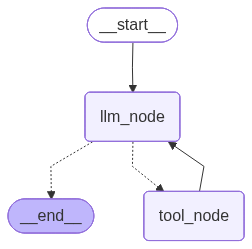

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_00_BoPaBKHmYUKDrRRVcStg6969)
 Call ID: call_00_BoPaBKHmYUKDrRRVcStg6969
  Args:
    a: 3
    b: 4
================================= Tool Message =================================

7
================================== Ai Message ==================================

3 + 4 = 7


In [19]:
# 6. 构建并编译Agent
# Build workflow
agent_builder = StateGraph(MessagesState)

# Add nodes
agent_builder.add_node("llm_node", llm_node)
agent_builder.add_node("tool_node", tool_node)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_node")
agent_builder.add_conditional_edges(
    "llm_node",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_node")

# Compile the agent
agent = agent_builder.compile()

# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="Add 3 and 4.")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

In [7]:
@tool('test_tool')
def tools_1():
    """"
     This is a test tool.
    """
    return 'This is a test tool.'
tools_1.name

'test_tool'